In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from analysis_by_plot import draw_floorplan
from utils import spl

In [2]:
n_trial = 50
ls_var = 'x', 'y'

In [3]:
record_dir = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/yihe/records/'
experiment_id = 'benchmark' 

data_dir = os.path.join(record_dir, experiment_id)

model_names = 'MB4ONdiagonal', 'MB4ONaxial', 'MB2ONbilateral', 'MB2ONopponent'
ls_color = 'tab:red', 'tab:blue', 'tab:orange', 'tab:green'

In [4]:
total_task = 100

task = {'scene_name': [], 'shortest_dist': [], 'shortest_path': []}
performance = {}
useful_idx = []
for model_name in model_names:
    performance[model_name] = {'collision': [], 'spl': []}

for ti, trial_id in enumerate(np.sort(os.listdir(data_dir))[:total_task]):
    trial_dir = os.path.join(data_dir, trial_id)
    
    alldata = {}
    for model_name in model_names:
        alldata[model_name] = {'steer': [], 'xy': []}
        
    for trial in range(n_trial):
        for model_name in model_names:
            data_name = 'Freight_{}_trial_{}_record.npz'.format(model_name, trial)
            data = np.load(os.path.join(trial_dir, data_name), allow_pickle=True)
            
            alldata[model_name]['steer'].append(data['extra'][()]['steer_mode'])
            alldata[model_name]['xy'].append([data['x'], data['y']])

    scene_name = data['scene_name']
    pos_goal = data['pos_goal'][:2]
    shortest_dist = data['optimal_route'][1]
    
    for model_name in model_names:
        n_collision = [np.count_nonzero(steer == 'reflex') for steer in alldata[model_name]['steer']]

        val_spl = [spl(np.transpose(path), pos_goal, shortest_dist) for path in alldata[model_name]['xy']]
        performance[model_name]['collision'].append(n_collision)
        performance[model_name]['spl'].append(val_spl)

        if model_name == model_names[0]:
            task['scene_name'].append(scene_name)
            task['shortest_dist'].append(shortest_dist)
            if np.sum(n_collision) > 0:
                useful_idx.append(ti)
                

In [5]:
n_useful_task = len(useful_idx)
print(n_useful_task, total_task)

63 100


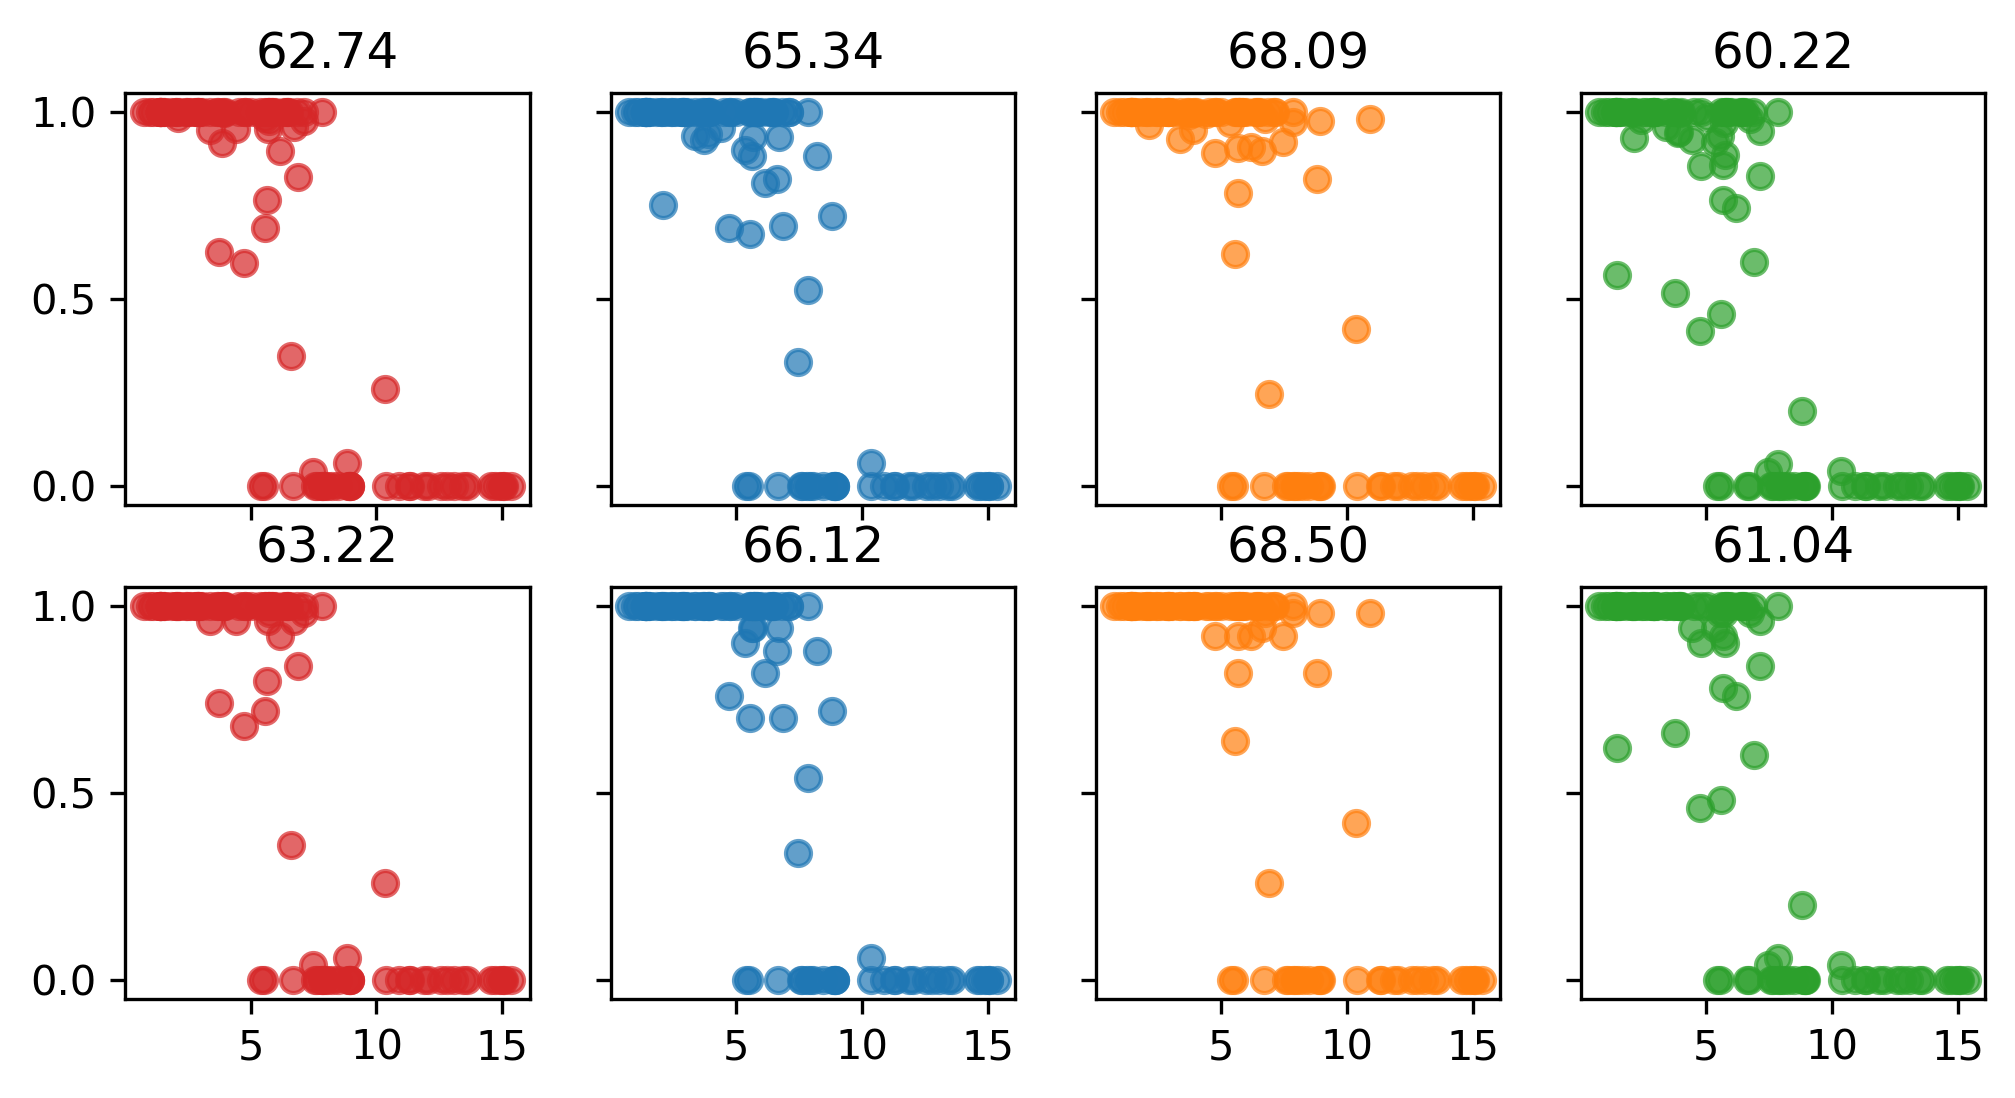

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4), dpi=300, sharex=True, sharey=True)
for model_name, c, axcol in zip(model_names, ls_color, axes.T):
    axcol[0].scatter(task['shortest_dist'], np.mean(performance[model_name]['spl'], axis=1), label=model_name,
               color=c, alpha=0.7)
    avg_spl = np.mean(performance[model_name]['spl'])
    
    
    axcol[1].scatter(task['shortest_dist'], np.count_nonzero(performance[model_name]['spl'], axis=1) / n_trial, label=model_name,
               color=c, alpha=0.7)    
    success_rate = np.count_nonzero(np.array(performance[model_name]['spl']) > 0) / (n_trial * total_task)
    
    
    axcol[0].set_title('{:.2f}'.format(avg_spl * 100))
    axcol[1].set_title('{:.2f}'.format(success_rate * 100))
    


In [7]:
steps = 500 * 50, 5.00E+06, 7.50E+07, 2.50E+09
allperf = [65.34, 44, 46, 92.9], [66.12, 44, 64, 99.1]

steps_slam = 5.00E+06, 7.50E+07
allperf_slam = [6.1, 51], [9.4, 62]

xlb = 'ours', '[Mishkin et al 2019]', '[Savva et al 2019]', '[Wijmans et al 2020]'

Text(0, 0.5, 'percentage (%)')

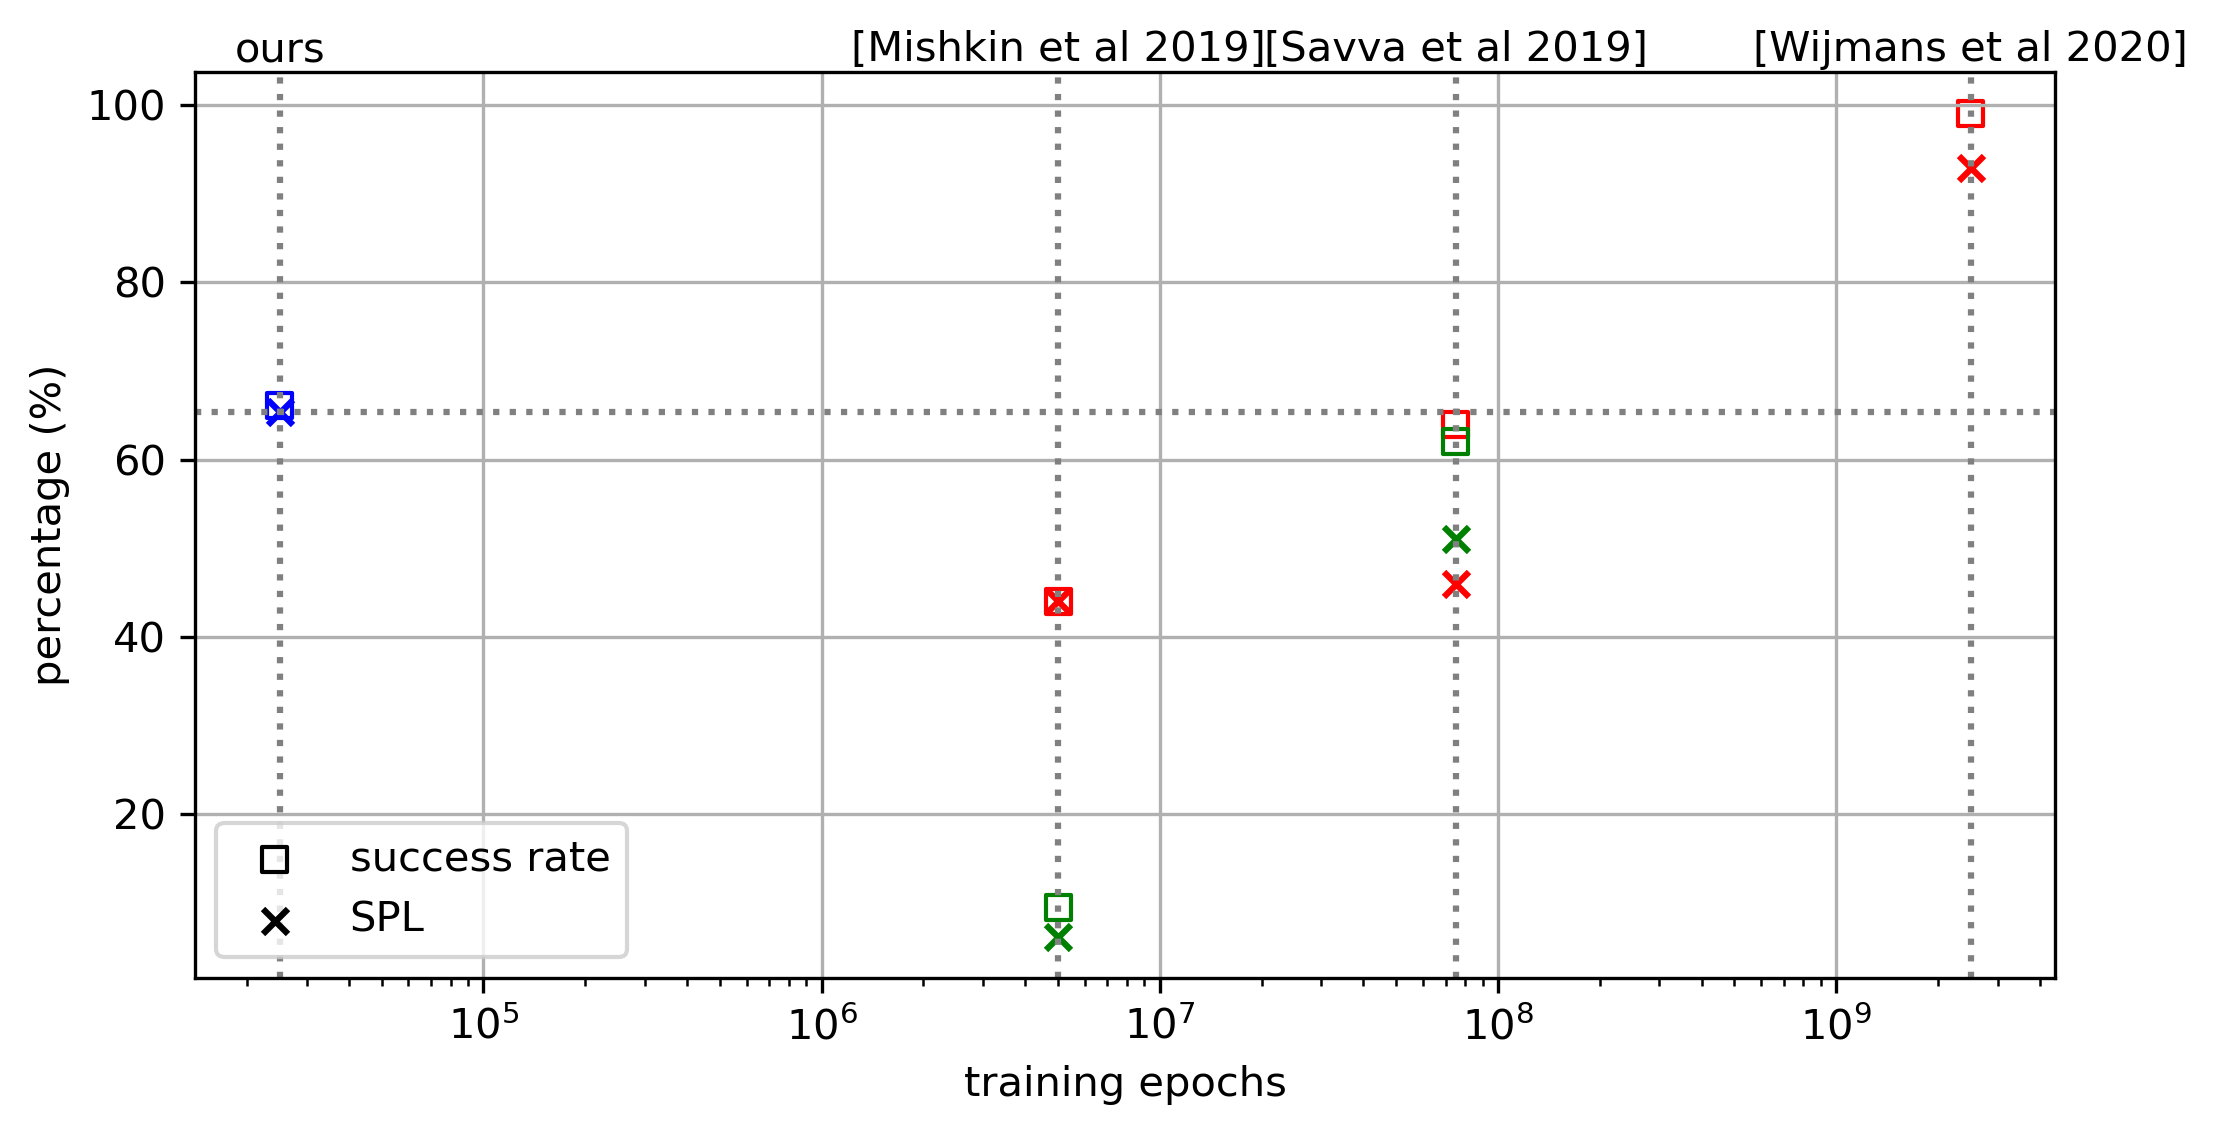

In [8]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

for s, xl in zip(steps, xlb):
    ax.axvline(s, ls='dotted', color='grey')
    ax.text(s, 105, xl, rotation=0, horizontalalignment='center')
    
ax.axhline(allperf[0][0], ls='dotted', color='grey')

ax.scatter(steps[0], allperf[0][0], marker='x', color='b')
ax.scatter(steps[0], allperf[1][0], marker='s', facecolor='none', edgecolor='b')

ax.scatter(steps[1:], allperf[0][1:], marker='x', color='r')
ax.scatter(steps[1:], allperf[1][1:], marker='s', facecolor='none', edgecolor='r')

ax.scatter(steps_slam, allperf_slam[0], marker='x', color='g')
ax.scatter(steps_slam, allperf_slam[1], marker='s', facecolor='none', edgecolor='g')

ax.scatter([], [], marker='s', facecolor='none', edgecolor='k', label='success rate')
ax.scatter([], [], marker='x', color='k', label='SPL')


ax.set_xscale('log')
ax.grid()
ax.legend(loc=3)

ax.set_xlabel('training epochs')
ax.set_ylabel('percentage (%)')

In [9]:
n_bins = 20
counts, bins = np.histogram(task['shortest_dist'], bins=n_bins)
distmax = 2.133 * 0.3 / 30 * 500

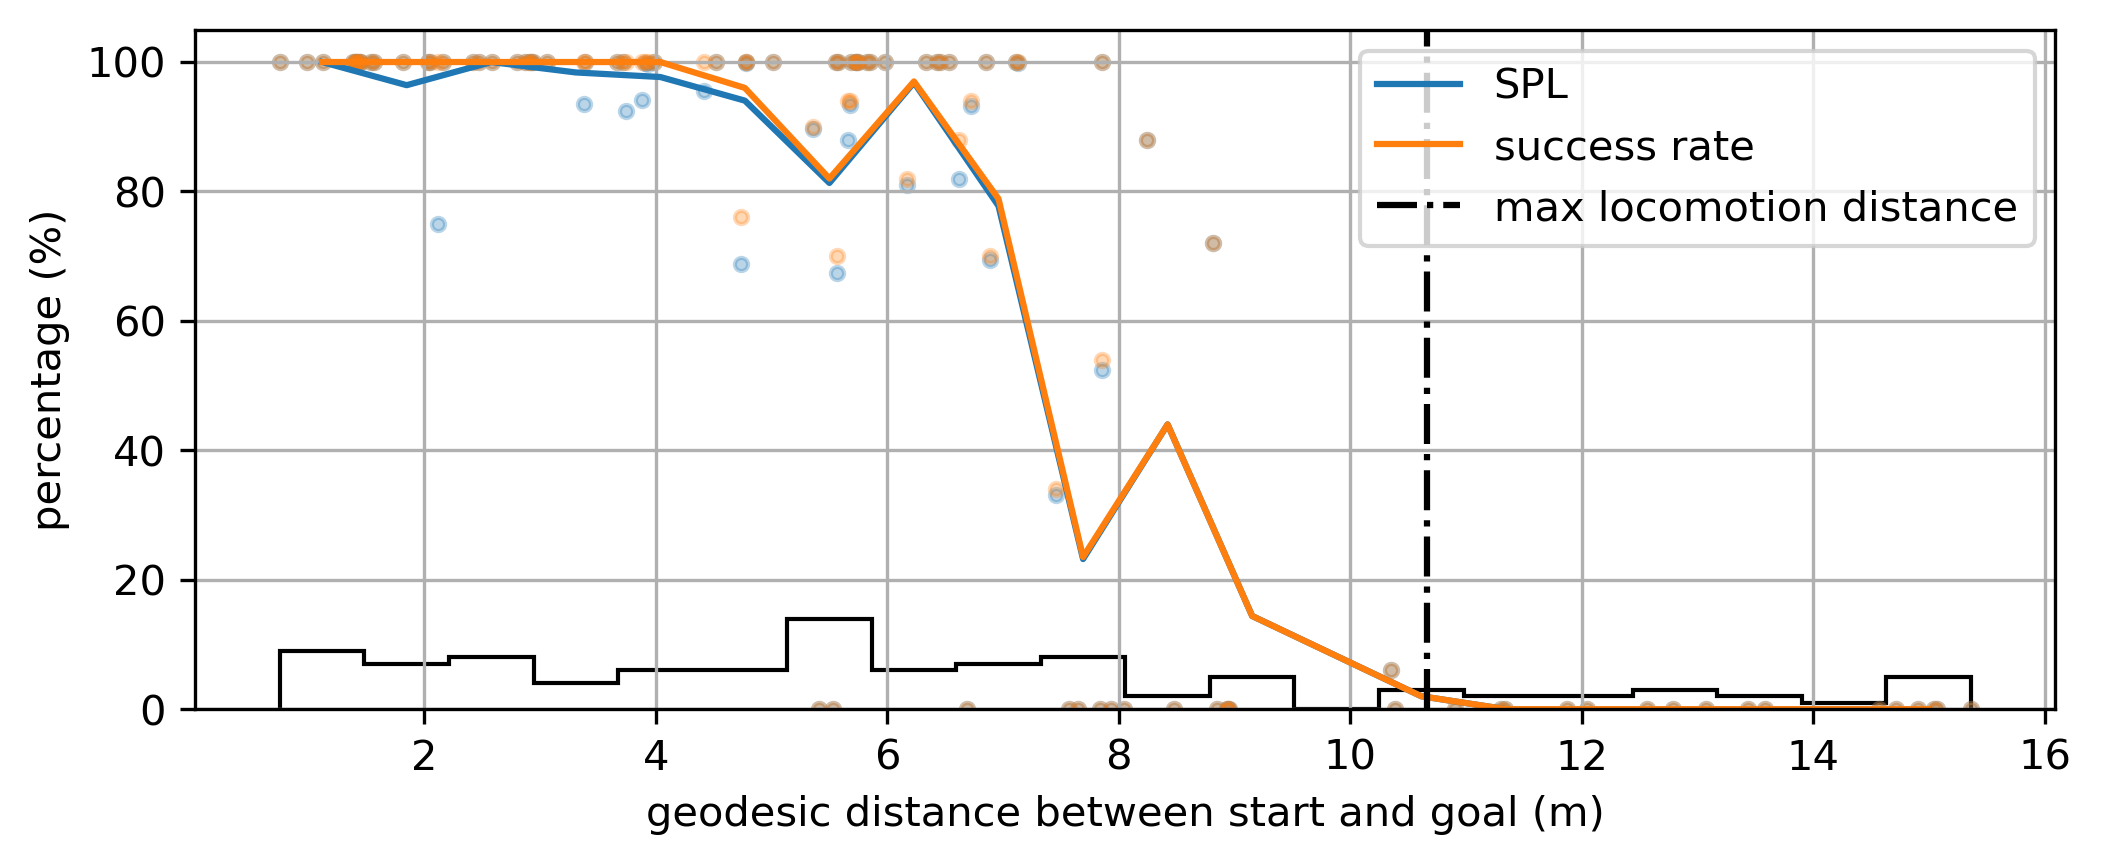

In [10]:
fig, ax = plt.subplots(figsize=(8, 3), dpi=300)
ax.stairs(counts / np.sum(counts) * 100, bins, color='k', label='')

model_name = model_names[1]
xx = task['shortest_dist']
for metric in ('SPL', 'success rate'):
    if metric == 'SPL':
        yy = np.mean(performance[model_name]['spl'], axis=1)
    else:
        yy = np.count_nonzero(performance[model_name]['spl'], axis=1) / n_trial
    yy *= 100
    
    ax.scatter(xx, yy, 
               alpha=0.3, s=10)
    
    bin_idx = np.digitize(xx, bins) - 1
    mean_yy = np.array([yy[bin_idx == i].mean() if len(yy[bin_idx == i]) > 0 else np.nan for i in range(n_bins)])
#     std_yy = np.array([yy[bin_idx == i].std() if len(yy[bin_idx == i]) > 0 else np.nan for i in range(n_bins)])
    for i in range(n_bins):
        if np.isnan(mean_yy[i]):
            if i == 0:
                mean_yy[i] = mean_yy[i + 1]
            elif i == n_bins - 1:
                mean_yy[i] = mean_yy[i - 1]
            else:
                mean_yy[i] = (mean_yy[i - 1] + mean_yy[i + 1]) / 2
    ax.plot((bins[1:] + bins[:-1]) / 2, mean_yy, label=metric)
#     ax.fill_between(bins[:-1], mean_yy - std_yy, mean_yy + std_yy)

ax.axvline(distmax, color='k', ls='-.', label='max locomotion distance')

ax.grid()
ax.set_xlabel('geodesic distance between start and goal (m)')
ax.set_ylabel('percentage (%)')
ax.legend()